<a href="https://colab.research.google.com/github/ravithreni02/agrigenie/blob/main/Model_training_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"

df = pd.read_csv("Crop_recommendation.csv")

X = df[FEATURES]
y_raw = df[TARGET].values

le = LabelEncoder()
y = le.fit_transform(y_raw)

# ---------------------------------------------------------------------------
# 1. Train/test split + final Random Forest model (the one the app uses)
# ---------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_s, y_train)
preds = rf.predict(X_test_s)

print("Holdout accuracy:", accuracy_score(y_test, preds))
print("Holdout F1 macro:", f1_score(y_test, preds, average="macro"))

joblib.dump(rf, "best_model_RandomForest.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(le, "label_encoder.joblib")



Holdout accuracy: 0.9954545454545455
Holdout F1 macro: 0.9954517027687758


['label_encoder.joblib']

Per-fold accuracy: [0.9955 0.9932 0.9977 0.9977 0.9909]
Mean accuracy: 0.9950 (+/- 0.0027)
Per-fold F1 macro: [0.9954 0.9932 0.9977 0.9977 0.9909]
Mean F1 macro: 0.9950 (+/- 0.0027)


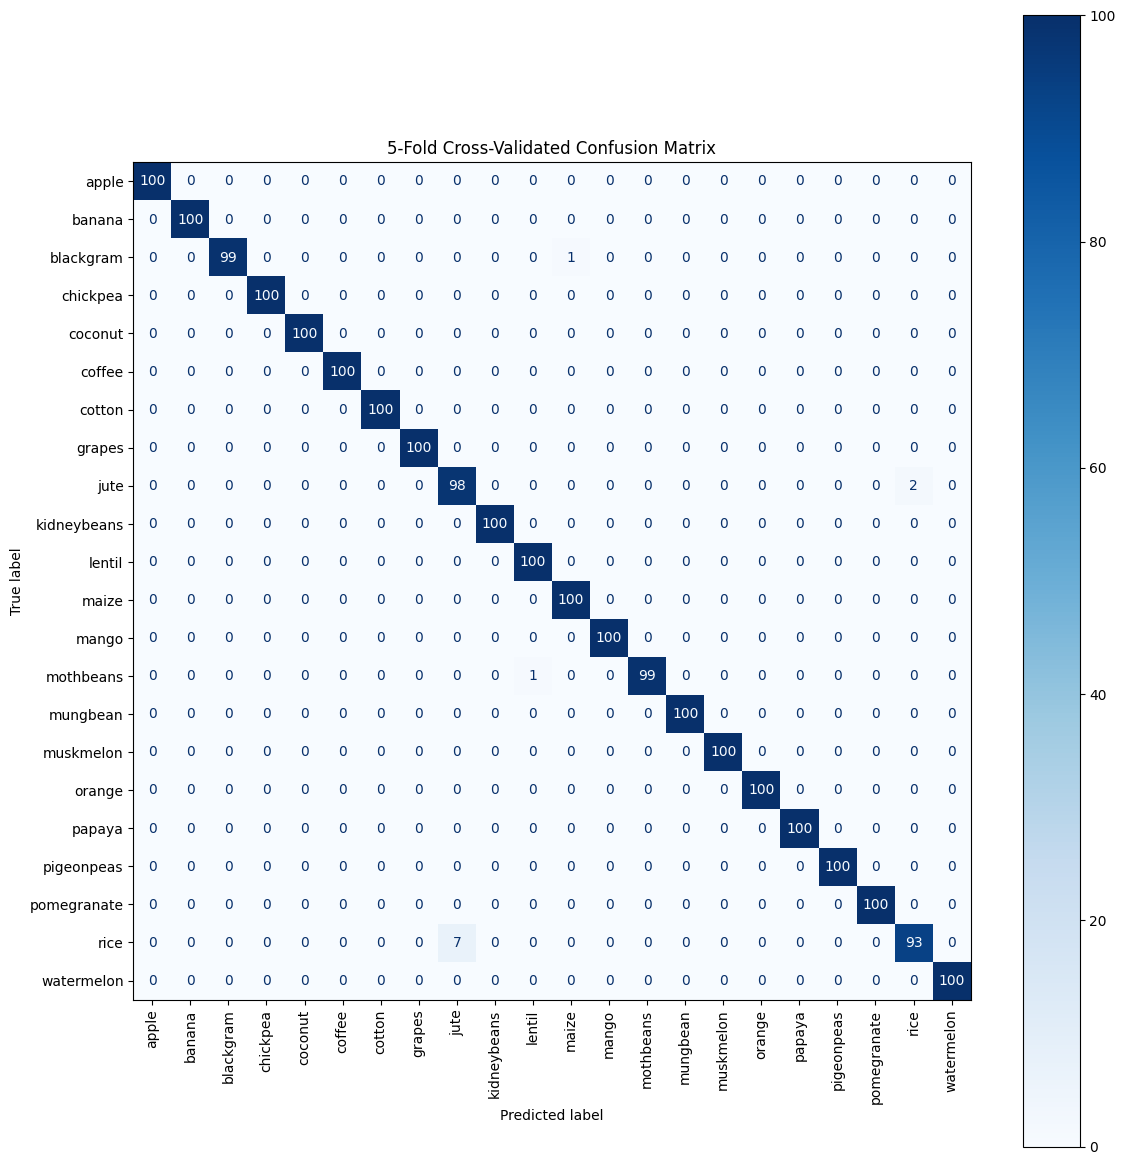

In [4]:
# ---------------------------------------------------------------------------
# 2. 5-fold cross-validation + confusion matrix for the Random Forest model
# ---------------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_scaled = scaler.fit_transform(X)

cv_accuracy = cross_val_score(rf, X_scaled, y, cv=skf, scoring="accuracy")
cv_f1_macro = cross_val_score(rf, X_scaled, y, cv=skf, scoring="f1_macro")

print("Per-fold accuracy:", np.round(cv_accuracy, 4))
print(f"Mean accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
print("Per-fold F1 macro:", np.round(cv_f1_macro, 4))
print(f"Mean F1 macro: {cv_f1_macro.mean():.4f} (+/- {cv_f1_macro.std():.4f})")

y_pred_cv = cross_val_predict(rf, X_scaled, y, cv=skf)
cm = confusion_matrix(y, y_pred_cv)

fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, xticks_rotation=90, cmap="Blues")
plt.title("5-Fold Cross-Validated Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


In [5]:
-# ---------------------------------------------------------------------------
# 3. Model comparison across all classifiers tried during development
# ---------------------------------------------------------------------------
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, eval_metric="mlogloss", random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, random_state=42, verbose=-1),
}

comparison_results = []
for name, model in models.items():
    acc_scores = cross_val_score(model, X_scaled, y, cv=skf, scoring="accuracy")
    f1_scores = cross_val_score(model, X_scaled, y, cv=skf, scoring="f1_macro")
    comparison_results.append({
        "model": name,
        "mean_accuracy": acc_scores.mean(),
        "std_accuracy": acc_scores.std(),
        "mean_f1_macro": f1_scores.mean(),
        "std_f1_macro": f1_scores.std(),
    })
    print(f"{name:20s} acc={acc_scores.mean():.4f} (+/-{acc_scores.std():.4f})  f1_macro={f1_scores.mean():.4f} (+/-{f1_scores.std():.4f})")

comparison_df = pd.DataFrame(comparison_results).sort_values("mean_accuracy", ascending=False)
comparison_df.to_csv("model_comparison_cv.csv", index=False)
print()
print(comparison_df.to_string(index=False))

LogisticRegression   acc=0.9714 (+/-0.0018)  f1_macro=0.9712 (+/-0.0018)
KNN                  acc=0.9714 (+/-0.0068)  f1_macro=0.9712 (+/-0.0068)
DecisionTree         acc=0.9877 (+/-0.0068)  f1_macro=0.9877 (+/-0.0068)
RandomForest         acc=0.9950 (+/-0.0027)  f1_macro=0.9950 (+/-0.0027)
SVM                  acc=0.9836 (+/-0.0044)  f1_macro=0.9836 (+/-0.0044)
XGBoost              acc=0.9936 (+/-0.0039)  f1_macro=0.9936 (+/-0.0039)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

LightGBM             acc=0.9918 (+/-0.0034)  f1_macro=0.9918 (+/-0.0034)

             model  mean_accuracy  std_accuracy  mean_f1_macro  std_f1_macro
      RandomForest       0.995000      0.002650       0.994993      0.002653
           XGBoost       0.993636      0.003910       0.993629      0.003915
          LightGBM       0.991818      0.003402       0.991796      0.003445
      DecisionTree       0.987727      0.006833       0.987724      0.006831
               SVM       0.983636      0.004407       0.983556      0.004448
               KNN       0.971364      0.006833       0.971212      0.006828
LogisticRegression       0.971364      0.001818       0.971189      0.001804


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
